In [1]:
import numpy as np
import pandas as pd
import pyvinecopulib as pv
from scipy.stats import rankdata

EXPORTERS = ['Saudi Arabia', 'UAE (Abu Dhabi)', 'Colombia', 'Mexico',
             'Brazil', 'Egypt', 'Malaysia', 'Qatar']
CONTROLS = ['Chile', 'China', 'Indonesia', 'Philippines',
            'South Africa', 'South Korea', 'Thailand', 'Turkey']

CDS_COL = 'cds_spread'

df = pd.read_csv('../output/Current_results/complete_results_weekly_15_dampening.csv')

In [2]:
def pseudo_uniform(x):
    n = len(x)
    return rankdata(x) / (n + 1)


def fit_pair(cds_vals, dd_vals):
    """
    Fit Gaussian and Clayton to (CDS, −DD) pseudo-uniforms.
    Flip DD so joint stress → lower-left tail for Clayton.
    """
    u = pseudo_uniform(cds_vals)
    v = pseudo_uniform(-dd_vals)  # flip
    data = np.asfortranarray(np.column_stack([u, v]))

    # Gaussian
    cop_g = pv.Bicop()
    cop_g.select(data, pv.FitControlsBicop(family_set=[pv.BicopFamily.gaussian]))
    rho = cop_g.parameters[0][0]
    aic_g = cop_g.aic(data)

    # Clayton
    cop_c = pv.Bicop()
    cop_c.select(data, pv.FitControlsBicop(family_set=[pv.BicopFamily.clayton]))
    theta = cop_c.parameters[0][0]
    aic_c = cop_c.aic(data)
    lambda_L = 2**(-1/theta) if theta > 0 else 0.0

    return {
        'Gauss_ρ': round(rho, 3),
        'Gauss_AIC': round(aic_g, 1),
        'Clayton_θ': round(theta, 3),
        'Clayton_λL': round(lambda_L, 3),
        'Clayton_AIC': round(aic_c, 1),
        'Best': 'Clayton' if aic_c < aic_g else 'Gaussian',
    }

In [3]:
models = {'M0': 'DD_M0', 'M1': 'DD_M1', 'M2': 'DD_M2'}
countries = EXPORTERS + CONTROLS
rows = []

for country in countries:
    group = 'Exporter' if country in EXPORTERS else 'Control'
    for mname, DD_COL in models.items():
        mask = df['country'] == country
        cds = df.loc[mask, CDS_COL].dropna()
        dd = df.loc[mask, DD_COL].dropna()
        idx = cds.index.intersection(dd.index)

        res = fit_pair(cds.loc[idx].values, dd.loc[idx].values)
        res.update({'Country': country, 'Group': group, 'Model': mname})
        rows.append(res)

results = pd.DataFrame(rows)
cols = ['Country', 'Group', 'Model', 'Gauss_ρ', 'Gauss_AIC',
        'Clayton_θ', 'Clayton_λL', 'Clayton_AIC', 'Best']
results = results[cols]
results

,Country,Group,Model,Gauss_ρ,Gauss_AIC,Clayton_θ,Clayton_λL,Clayton_AIC,Best
0,Saudi Arabia,Exporter,M0,0.686,-323.7,1.440,0.618,-258.3,Gaussian
1,Saudi Arabia,Exporter,M1,0.754,-429.6,1.925,0.698,-350.9,Gaussian
2,Saudi Arabia,Exporter,M2,0.718,-368.7,1.695,0.664,-292.0,Gaussian
3,UAE (Abu Dhabi),Exporter,M0,-0.122,-5.5,0.205,0.034,-13.8,Clayton
4,UAE (Abu Dhabi),Exporter,M1,0.415,-93.3,0.628,0.332,-99.1,Clayton
5,UAE (Abu Dhabi),Exporter,M2,0.388,-80.5,0.749,0.396,-135.4,Clayton
6,Colombia,Exporter,M0,0.496,-141.4,0.982,0.494,-58.7,Gaussian
7,Colombia,Exporter,M1,0.501,-144.3,0.900,0.463,-170.0,Clayton
8,Colombia,Exporter,M2,0.556,-186.0,1.175,0.554,-163.3,Gaussian
9,Mexico,Exporter,M0,0.363,-69.2,0.578,0.301,-79.7,Clayton


In [4]:
summary = (results.groupby(['Group', 'Model'])
           .agg(
               mean_λL=('Clayton_λL', 'mean'),
               clayton_pct=('Best', lambda x: f"{(x == 'Clayton').mean():.0%}"),
               mean_gauss_ρ=('Gauss_ρ', 'mean'),
           )
           .round(3))

print("\nCopula Summary: Group × Model")
print("=" * 55)
print(summary.to_string())


Copula Summary: Group × Model
                mean_λL clayton_pct  mean_gauss_ρ
Group    Model                                   
Control  M0       0.191         38%         0.113
         M1       0.306         62%         0.277
         M2       0.308         50%         0.314
Exporter M0       0.392         50%         0.428
         M1       0.469         50%         0.528
         M2       0.541         50%         0.571


In [5]:
rows = []
for group_name, group_countries in [('Exporter', EXPORTERS), ('Control', CONTROLS)]:
    for mname, DD_COL in models.items():
        u_pool, v_pool = [], []
        for country in group_countries:
            mask = df['country'] == country
            cds = df.loc[mask, CDS_COL].dropna()
            dd = df.loc[mask, DD_COL].dropna()
            idx = cds.index.intersection(dd.index)
            # rank within country, then collect
            u_pool.append(pseudo_uniform(cds.loc[idx].values))
            v_pool.append(pseudo_uniform(-dd.loc[idx].values))
        
        u = np.concatenate(u_pool)
        v = np.concatenate(v_pool)
        res = fit_pair(u, v)  # already takes pseudo-uniforms — skip internal ranking
        res.update({'Group': group_name, 'Model': mname})
        rows.append(res)

summary = pd.DataFrame(rows)[['Group', 'Model', 'Gauss_ρ', 'Gauss_AIC', 'Clayton_θ', 'Clayton_λL', 'Clayton_AIC', 'Best']]
summary

,Group,Model,Gauss_ρ,Gauss_AIC,Clayton_θ,Clayton_λL,Clayton_AIC,Best
0,Exporter,M0,-0.422,-811.0,0.583,0.304,-517.7,Gaussian
1,Exporter,M1,-0.523,-1321.1,0.831,0.434,-1030.9,Gaussian
2,Exporter,M2,-0.565,-1595.8,0.974,0.491,-1221.4,Gaussian
3,Control,M0,-0.112,-50.3,0.129,0.005,-52.4,Clayton
4,Control,M1,-0.275,-324.5,0.356,0.143,-306.7,Gaussian
5,Control,M2,-0.312,-422.9,0.463,0.223,-507.3,Clayton


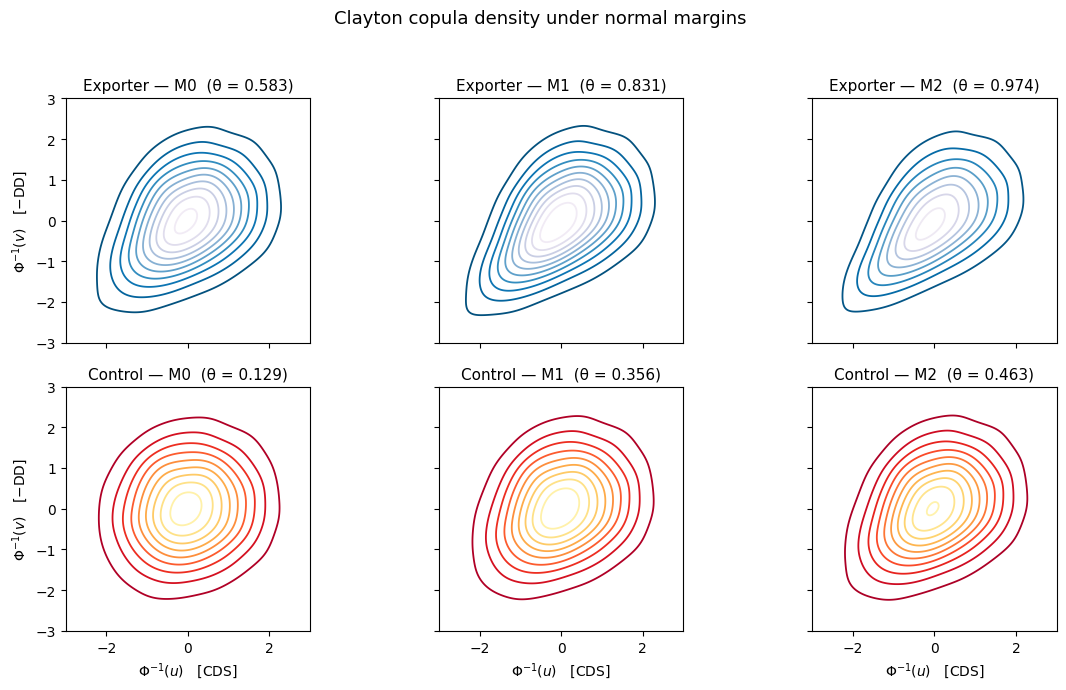

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, gaussian_kde
import pyvinecopulib as pv

thetas = {
    ('Exporter', 'M0'): 0.583,
    ('Exporter', 'M1'): 0.831,
    ('Exporter', 'M2'): 0.974,
    ('Control',  'M0'): 0.129,
    ('Control',  'M1'): 0.356,
    ('Control',  'M2'): 0.463,
}

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
groups = ['Exporter', 'Control']
models = ['M0', 'M1', 'M2']
cmaps = {'Exporter': 'PuBu_r', 'Control': 'YlOrRd_r'}

for i, group in enumerate(groups):
    for j, model in enumerate(models):
        ax = axes[i, j]
        theta = thetas[(group, model)]

        cop = pv.Bicop(family=pv.BicopFamily.clayton,
                       parameters=np.array([[theta]]))
        samples = cop.simulate(20000, seeds=[42])
        x = norm.ppf(samples[:, 0])
        y = norm.ppf(samples[:, 1])

        kde = gaussian_kde(np.vstack([x, y]), bw_method=0.3)
        grid = np.linspace(-3, 3, 200)
        X, Y = np.meshgrid(grid, grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        ax.contour(X, Y, Z, levels=10, cmap=cmaps[group], linewidths=1.3)
        ax.set_title(f'{group} — {model}  (θ = {theta:.3f})', fontsize=11)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect('equal')
        if i == 1:
            ax.set_xlabel(r'$\Phi^{-1}(u)$   [CDS]', fontsize=10)
        if j == 0:
            ax.set_ylabel(r'$\Phi^{-1}(v)$   [$-$DD]', fontsize=10)

fig.suptitle('Clayton copula density under normal margins', fontsize=13, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()